In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pickle
import os

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("All imports successful ✅")

All imports successful ✅


In [2]:
df = pd.read_csv('../data/attrition.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']

df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns dropped: {cols_to_drop}")
print(f"New shape: {df.shape}")

Columns dropped: ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
New shape: (1470, 31)


In [4]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Target encoding:")
print(df['Attrition'].value_counts())
print(f"\nAttrition dtype: {df['Attrition'].dtype}")

Target encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition dtype: int64


In [5]:
# Binary categorical (only 2 unique values)
binary_cols = [col for col in df.select_dtypes(include='object').columns
               if df[col].nunique() == 2]

# Multi-class categorical (more than 2 unique values)
multi_cols = [col for col in df.select_dtypes(include='object').columns
              if df[col].nunique() > 2]

# Ordinal numeric columns (encoded as numbers but are actually scales)
ordinal_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

# True continuous numeric columns
all_numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
continuous_cols = [col for col in all_numeric 
                   if col not in ordinal_cols and col != 'Attrition']

print(f"Binary categorical columns ({len(binary_cols)}): {binary_cols}")
print(f"\nMulti-class categorical columns ({len(multi_cols)}): {multi_cols}")
print(f"\nOrdinal columns ({len(ordinal_cols)}): {ordinal_cols}")
print(f"\nContinuous numeric columns ({len(continuous_cols)}): {continuous_cols}")

Binary categorical columns (2): ['Gender', 'OverTime']

Multi-class categorical columns (5): ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

Ordinal columns (9): ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

Continuous numeric columns (14): ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\USER\AppData\Local\Temp\ipykernel_32252\1810562312.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  binary_cols = [col for col in df.select_dtypes(include='object').columns
C:\Users\USER\AppData\Local\Temp\ipykernel_32252\1810562312.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

In [6]:
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}


In [7]:
print(f"Shape before One-Hot Encoding: {df.shape}")

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"Shape after One-Hot Encoding:  {df.shape}")
print(f"\nNew columns added:")
new_cols = [col for col in df.columns if any(m in col for m in multi_cols)]
print(new_cols)

Shape before One-Hot Encoding: (1470, 31)
Shape after One-Hot Encoding:  (1470, 45)

New columns added:
['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [8]:
remaining_object_cols = df.select_dtypes(include='object').columns.tolist()

if len(remaining_object_cols) == 0:
    print("All columns are numeric ✅")
else:
    print(f"Non-numeric columns still remaining: {remaining_object_cols}")

print(f"\nFinal dataframe shape: {df.shape}")
df.head()

All columns are numeric ✅

Final dataframe shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False


In [9]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y):   {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nAttrition rate: {y.mean()*100:.1f}%")

Features shape (X): (1470, 44)
Target shape (y):   (1470,)

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← ensures both splits keep the same 84/16 ratio
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"\nTraining attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test attrition rate:     {y_test.mean()*100:.1f}%")

Training set:   1176 rows
Test set:       294 rows

Training attrition rate: 16.2%
Test attrition rate:     16.0%


In [11]:
# Only scale columns that actually exist in X_train after encoding
cols_to_scale = [col for col in continuous_cols if col in X_train.columns]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(f"Scaled {len(cols_to_scale)} columns: {cols_to_scale}")
print("\nSample of scaled training data:")
X_train[cols_to_scale].describe().round(2).T[['mean', 'std', 'min', 'max']]

Scaled 14 columns: ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Sample of scaled training data:


,mean,std,min,max
Age,-0.0,1.0,-2.07,2.51
DailyRate,0.0,1.0,-1.75,1.73
DistanceFromHome,-0.0,1.0,-1.02,2.40
HourlyRate,-0.0,1.0,-1.74,1.69
MonthlyIncome,-0.0,1.0,-1.19,2.89
MonthlyRate,0.0,1.0,-1.71,1.75
NumCompaniesWorked,-0.0,1.0,-1.08,2.54
PercentSalaryHike,-0.0,1.0,-1.15,2.65
TotalWorkingYears,-0.0,1.0,-1.46,3.67
TrainingTimesLastYear,0.0,1.0,-2.20,2.58


In [12]:
print("Before SMOTE:")
print(f"  Class 0 (Stayed): {(y_train == 0).sum()}")
print(f"  Class 1 (Left):   {(y_train == 1).sum()}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Class 0 (Stayed): {(y_train_balanced == 0).sum()}")
print(f"  Class 1 (Left):   {(y_train_balanced == 1).sum()}")
print(f"\nNew training set size: {X_train_balanced.shape[0]} rows")

Before SMOTE:
  Class 0 (Stayed): 986
  Class 1 (Left):   190

After SMOTE:
  Class 0 (Stayed): 986
  Class 1 (Left):   986

New training set size: 1972 rows


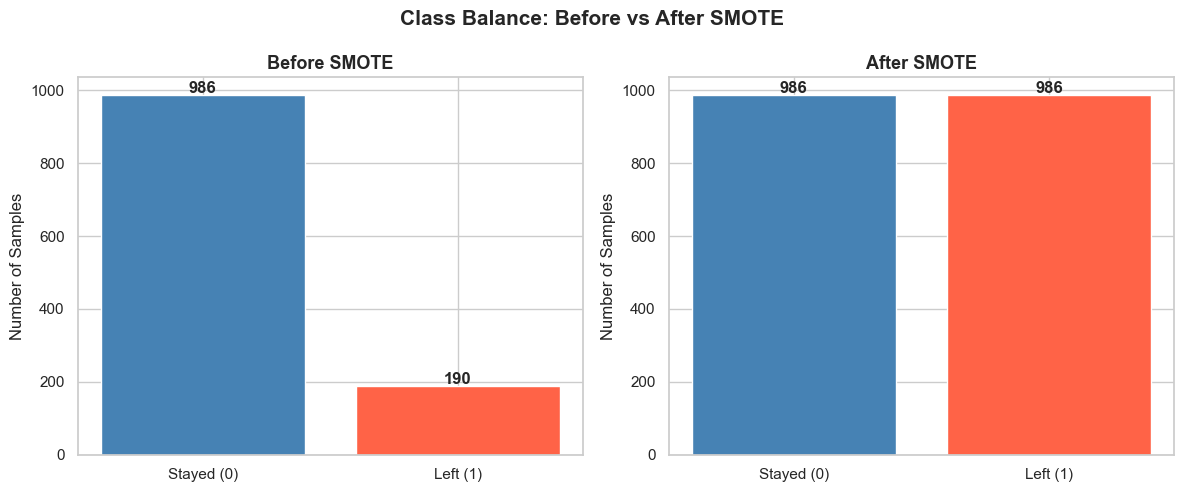

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
axes[0].bar(['Stayed (0)', 'Left (1)'],
            [( y_train == 0).sum(), (y_train == 1).sum()],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# After
axes[1].bar(['Stayed (0)', 'Left (1)'],
            [(y_train_balanced == 0).sum(), (y_train_balanced == 1).sum()],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('After SMOTE', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate([(y_train_balanced==0).sum(), (y_train_balanced==1).sum()]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
os.makedirs('../models', exist_ok=True)

# Save the processed datasets
X_train_balanced.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
pd.Series(y_train_balanced, name='Attrition').to_csv('../data/y_train.csv', index=False)
pd.Series(y_test, name='Attrition').to_csv('../data/y_test.csv', index=False)

# Save the scaler (we'll need it later in the app)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the feature column names (important for the app later)
feature_columns = X_train.columns.tolist()
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Saved successfully:")
print("  ✅ data/X_train.csv")
print("  ✅ data/X_test.csv")
print("  ✅ data/y_train.csv")
print("  ✅ data/y_test.csv")
print("  ✅ models/scaler.pkl")
print("  ✅ models/feature_columns.pkl")

Saved successfully:
  ✅ data/X_train.csv
  ✅ data/X_test.csv
  ✅ data/y_train.csv
  ✅ data/y_test.csv
  ✅ models/scaler.pkl
  ✅ models/feature_columns.pkl


In [15]:
print("=" * 50)
print("PREPROCESSING COMPLETE — FINAL SUMMARY")
print("=" * 50)
print(f"Training samples (after SMOTE): {X_train_balanced.shape[0]}")
print(f"Test samples:                   {X_test.shape[0]}")
print(f"Number of features:             {X_train_balanced.shape[1]}")
print(f"Target balance (train):         {pd.Series(y_train_balanced).value_counts().to_dict()}")
print(f"Target balance (test):          {pd.Series(y_test).value_counts().to_dict()}")
print(f"\nTest set remains untouched and imbalanced ✅")
print(f"(This is correct — test set should reflect real-world distribution)")

PREPROCESSING COMPLETE — FINAL SUMMARY
Training samples (after SMOTE): 1972
Test samples:                   294
Number of features:             44
Target balance (train):         {0: 986, 1: 986}
Target balance (test):          {0: 247, 1: 47}

Test set remains untouched and imbalanced ✅
(This is correct — test set should reflect real-world distribution)
